# Simple Transformer — CUDA Only

This notebook is a CUDA-optimized copy of `TestSimpleTransformerApple.ipynb`.
- Enforces CUDA-only execution (raises if no CUDA).
- Uses AMP (autocast + GradScaler), TF32, and CUDA-friendly DataLoader settings.
- Removes MPS-specific logic and workarounds.


In [1]:
import os, sys, math, json, inspect
from typing import List, Tuple, Dict, Optional, Sequence, Any
from contextlib import contextmanager

import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Enforce CUDA-only execution
if not torch.cuda.is_available():
    raise RuntimeError('CUDA device is required for this notebook. Exiting.')

device = torch.device('cuda')
print(f'Using device: {device}')

# CUDA performance settings
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass
# Prefer BF16 if supported, else FP16
is_bf16_supported = getattr(torch.cuda, 'is_bf16_supported', lambda: False)()
AMP_DTYPE = torch.bfloat16 if is_bf16_supported else torch.float16

# Pick AMP API by feature detection (works across PyTorch versions)
USE_NEW_AMP = hasattr(torch, 'autocast') and hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler')
GradScalerAlias = torch.amp.GradScaler if USE_NEW_AMP else torch.cuda.amp.GradScaler
SCALER = GradScalerAlias(enabled=True)

@contextmanager
def amp_autocast(dtype=AMP_DTYPE):
    if USE_NEW_AMP:
        with torch.autocast(device_type='cuda', dtype=dtype):
            yield
    else:
        with torch.cuda.amp.autocast(dtype=dtype):
            yield

# Enable Flash/Mem-Efficient SDPA kernels if available (speeds up attention)
try:
    from torch.backends.cuda import sdp_kernel
    sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True)
except Exception:
    try:
        torch.backends.cuda.enable_flash_sdp(True)
        torch.backends.cuda.enable_mem_efficient_sdp(True)
        torch.backends.cuda.enable_math_sdp(False)
    except Exception:
        pass

# Local package imports
sys.path.append('../../')
from pqcqec.utils.constants import QUBITS_FOR_GATES, QISKIT_GATES, GATE_IS_DIRECTIONAL


Using device: cuda


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


## Tokenizer / Encoder

In [2]:
from itertools import permutations, combinations

class SimpleCircuitTokenizer:
    """
    Tokenizes quantum circuit operations into unique integer IDs.
    """
    def __init__(
        self,
        gateset: Sequence[str],
        num_qubits: int,
        qubits_for_gates: dict[str, int],
        undirected_gates: Sequence[str] | None = None,
    ):
        if num_qubits < 1:
            raise ValueError('Number of qubits must be at least 1.')
        self.num_qubits = num_qubits
        self.gates = {g.lower() for g in gateset}
        self.undirected = {g.lower() for g in (undirected_gates or [])}
        self.qubits_for_gates = {g.lower(): qubits_for_gates[g] for g in qubits_for_gates}
        if not self.undirected.issubset(self.gates):
            unknown = self.undirected - self.gates
            raise ValueError(f'Undirected gates {unknown} are not in the main gateset.')
        self.pad_id = 0
        self.pad_gate = 'pad'
        self.pad_token = (self.pad_gate, ())
        self.op_to_id: dict[tuple[str, tuple[int, ...]], int] = {self.pad_token: self.pad_id}
        self.id_to_op: dict[int, tuple[str, tuple[int, ...]]] = {self.pad_id: self.pad_token}
        self._build_vocab()

    @property
    def vocab_size(self) -> int:
        return len(self.op_to_id)

    def _build_vocab(self) -> None:
        sorted_gates = sorted(self.gates)
        next_id = len(self.id_to_op)
        qubits = range(self.num_qubits)
        for g in sorted_gates:
            q_count = self.qubits_for_gates.get(g, None)
            qubit_tokens = list(combinations(qubits, q_count)) if g in self.undirected else list(permutations(qubits, q_count))
            for qs in qubit_tokens:
                op = (g, tuple(qs))
                self.op_to_id[op] = next_id
                self.id_to_op[next_id] = op
                next_id += 1

    def _canonicalize_op(self, gate: str, qubits: Sequence[int]) -> tuple[str, tuple[int, ...]]:
        g = gate.lower()
        if g not in self.gates:
            raise ValueError(f"Gate '{gate}' is not in the tokenizer's gateset.")
        qs = tuple(qubits)
        if not (1 <= len(qs) <= 2):
            raise ValueError(f'Only 1- and 2-qubit operations are supported, but got {len(qs)} qubits for gate "{gate}".')
        for q in qs:
            if not (0 <= q < self.num_qubits):
                raise ValueError(f'Qubit index {q} is out of range for a device with {self.num_qubits} qubits.')
        if len(qs) == 2:
            if qs[0] == qs[1]:
                raise ValueError('A 2-qubit operation must act on two different qubits.')
            if g in self.undirected:
                qs = tuple(sorted(qs))
        return g, qs

    def encode(self, circuit: Sequence[tuple[str, Sequence[int], Any]]) -> list[int]:
        token_ids = []
        for gate, qubits, *_ in circuit:
            op = self._canonicalize_op(gate, qubits)
            token_ids.append(self.op_to_id[op])
        return token_ids

    def decode(self, token_ids: Sequence[int]) -> list[list[Any]]:
        circuit = []
        for token_id in token_ids:
            if token_id == self.pad_id:
                continue
            if token_id not in self.id_to_op:
                raise KeyError(f'Token ID {token_id} is not in the vocabulary.')
            gate, qubits = self.id_to_op[token_id]
            circuit.append([gate, list(qubits), []])
        return circuit

    def print_vocab(self, limit: int | None = 20) -> None:
        for token_id in sorted(self.id_to_op.keys())[:limit]:
            gate, qubits = self.id_to_op[token_id]
            print(f"ID {token_id:3}: Gate '{gate}' on qubits {qubits}")


In [3]:
class SimpleCircuitDataset(Dataset):
    def __init__(self, tokenizer: SimpleCircuitTokenizer, circuit_data: List):
        self.tokenizer = tokenizer
        self.circuit_data = circuit_data

    def __len__(self) -> int:
        return len(self.circuit_data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        circuit, params, fidelity = self.circuit_data[idx]
        input_ids = self.tokenizer.encode(circuit)
        attention_mask = [1 for x in input_ids if x != self.tokenizer.pad_id]
        transformer_dict = {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        }
        params_tensor = torch.tensor(params, dtype=torch.float)
        fidelity_tensor = torch.tensor(fidelity, dtype=torch.float)
        return transformer_dict, params_tensor, fidelity_tensor


## Model

In [4]:
class PositionalEncodingBF(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe, persistent=False)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class SimpleTransformer(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 out_shape: tuple,
                 d_model: int = 128,
                 nhead: int = 2,
                 num_encoder_layers: int = 2,
                 dim_feedforward: int = 256,
                 dropout: float = 0.1,
                 pad_id: int = 0,
                 max_len: int = 128):
        super().__init__()
        self.K, self.Q, self.P = out_shape
        self.out_dim = self.K * self.Q * self.P
        self.d_model = d_model
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoder = PositionalEncodingBF(d_model, dropout, max_len=max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)
        self.regression_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, self.out_dim)
        )
    def forward(self, input_ids, attention_mask=None):
        is_batched = input_ids.dim() == 2
        if not is_batched:
            input_ids = input_ids.unsqueeze(0)
            if attention_mask is not None:
                attention_mask = attention_mask.unsqueeze(0)
        x = self.embedding(input_ids.long()) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        if attention_mask is None:
            pad_mask = (input_ids == self.pad_id)
        else:
            pad_mask = ~attention_mask.bool()
        # On CUDA, always pass the key padding mask
        x = self.encoder(x, src_key_padding_mask=pad_mask)
        mask = (~pad_mask).unsqueeze(-1).float()
        denom = mask.sum(dim=1).clamp_min(1.0)
        pooled = (x * mask).sum(dim=1) / denom
        y = self.regression_head(pooled)
        y = y.view(-1, self.K, self.Q, self.P)
        if not is_batched:
            y = y.squeeze(0)
        return y


## Loss

In [5]:
def cosine_loss(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> torch.Tensor:
    cos_loss = 1 - torch.cos(pred_angles - target_angles)
    return cos_loss.mean()


## Train / Eval Helpers (CUDA + AMP)

In [6]:
@torch.no_grad()
def evaluate_epoch(model: nn.Module, dataloader, loss_fn, device: torch.device) -> float:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    for batch in dataloader:
        x, y, _ = batch
        input_ids = x['input_ids'].to(device, non_blocking=True)
        attention_mask = x.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device, non_blocking=True)
        target = y.to(device, non_blocking=True)
        with amp_autocast(dtype=AMP_DTYPE):
            pred = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(pred, target)
        total_loss += float(loss.detach().cpu())
        total_batches += 1
    return total_loss / max(1, total_batches)

def train_epoch(model: nn.Module, dataloader, optimizer: torch.optim.Optimizer, loss_fn, device: torch.device, grad_clip: Optional[float] = None) -> float:
    model.train()
    total_loss = 0.0
    total_batches = 0
    for batch in dataloader:
        x, y, _ = batch
        input_ids = x['input_ids'].to(device, non_blocking=True)
        attention_mask = x.get('attention_mask', None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device, non_blocking=True)
        target = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_autocast(dtype=AMP_DTYPE):
            pred = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(pred, target)
        SCALER.scale(loss).backward()
        if grad_clip is not None:
            SCALER.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        SCALER.step(optimizer)
        SCALER.update()
        total_loss += float(loss.detach().cpu())
        total_batches += 1
    return total_loss / max(1, total_batches)

def train(model: nn.Module, train_loader, val_loader, optimizer: torch.optim.Optimizer, loss_fn, device: torch.device, epochs: int = 10, grad_clip: Optional[float] = None):
    train_hist, val_hist = [], []
    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device, grad_clip)
        va_loss = evaluate_epoch(model, val_loader, loss_fn, device)
        train_hist.append(tr_loss); val_hist.append(va_loss)
        print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
    return train_hist, val_hist


## Constants

In [7]:
PQC_GATES = ['rz', 'rx', 'rz']
DATA_PATH = '../../nogit/quaternion/uncomp/rzrxrz/large/5q_10g_5blk_data/'
GOOD_DATA_PATH = DATA_PATH + 'good_fidelity/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'
CONFIG_PATH = DATA_PATH + 'config.json'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)
print(CONFIG)

HAS_UNCOMP = CONFIG.get('uncomp', True)
NUM_QUBITS = CONFIG.get('qubits', 3)[0]
NUM_GATES = CONFIG.get('gates', 4)[0] * (2 if HAS_UNCOMP else 1)
GATE_BLOCKS = CONFIG.get('gate_blocks', 4)
VALID_GATES = CONFIG.get('gate_dist')
if VALID_GATES is None:
    VALID_GATES = ['x', 'z', 'h', 'cx', 'cz']
else :
    VALID_GATES = [g.lower() for g in VALID_GATES if g.lower() in QISKIT_GATES]

#VALID_GATES = list(CONFIG.get('gate_dist', QISKIT_GATES).keys()) --- IGNORE ---

print(f'Using {NUM_QUBITS} qubits, {NUM_GATES} gates, {GATE_BLOCKS} gate blocks, {VALID_GATES} valid gates. The dataset has {"uncomputed" if HAS_UNCOMP else "regular"} states.')

PAD_ID = 0
UNDIRECTED_GATES = [gate for gate in VALID_GATES if not GATE_IS_DIRECTIONAL.get(gate, False)]
print('Undirected Gates in circuit:', UNDIRECTED_GATES)

NOISE_DIST = CONFIG.get("noise_dist", {})
print(f'Noise Dist: {NOISE_DIST}')

TRAIN_SZ = 0.8
VAL_SZ = 0.1
TEST_SZ = 0.1
BATCH_SIZE = 64
LEARNING_RATE = 1e-6
WEIGHT_DECAY = 1e-3
D_MODEL = 256
NUM_HEADS = 4
NUM_ENCODER_LAYERS = 4
DIM_FEEDFORWARD = 1024
DROPOUT = 0.1
MAX_LEN = 128
EPOCHS = 100
GRAD_CLIP = 1.0

# # OneCycleLR scheduler hyperparameters (align with Apple notebook logic)
# SCHEDULER_WARMUP_FRAC = 0.2
# SCHEDULER_MAX_LR = 1e-5
# SCHEDULER_DIV_FACTOR = 10
# SCHEDULER_FINAL_DIV_FACTOR = 1e4


{'config': 'nogit/quaternion/uncomp/rzrxrz/large/5q_10g_5blk_data/config.json', 'qubit_range': [5], 'gate_range': [10], 'pqc_blocks': 1, 'gate_blocks': 5, 'figure_output': 'nogit/quaternion/uncomp/rzrxrz/large', 'epochs': 3, 'num_data': 2500, 'num_test': 50, 'seed': '50000', 'gate_dist': None, 'noise_dist': {'x_rad': 0.01, 'z_rad': 0.01, 'delta_x': 5, 'delta_z': 5}, 'gpu': False, 'batch': 25, 'force': False, 'redo': False, 'mp_cores': 0, 'uncomp': True, 'qubits': [5], 'gates': [10], 'device': 'cpu'}
Using 5 qubits, 20 gates, 5 gate blocks, ['x', 'z', 'h', 'cx', 'cz'] valid gates. The dataset has uncomputed states.
Undirected Gates in circuit: ['x', 'z', 'h', 'cz']
Noise Dist: {'x_rad': 0.01, 'z_rad': 0.01, 'delta_x': 5, 'delta_z': 5}


## Load Data

In [8]:
good_data = []
poor_data = []
for filename in os.listdir(GOOD_DATA_PATH):
    with open(os.path.join(GOOD_DATA_PATH, filename), 'r') as f:
        token_dict = json.load(f)
        good_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
for filename in os.listdir(BAD_DATA_PATH):
    with open(os.path.join(BAD_DATA_PATH, filename), 'r') as f:
        token_dict = json.load(f)
        poor_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
print(f'Number of good data samples: {len(good_data)}')
print(f'Number of poor data samples: {len(poor_data)}')

qc_tokenizer = SimpleCircuitTokenizer(gateset=VALID_GATES, num_qubits=NUM_QUBITS, undirected_gates=UNDIRECTED_GATES, qubits_for_gates=QUBITS_FOR_GATES)
print(f'Vocabulary size: {qc_tokenizer.vocab_size}')
qc_good_dataset = SimpleCircuitDataset(qc_tokenizer, good_data)
qc_poor_dataset = SimpleCircuitDataset(qc_tokenizer, poor_data)
print(f'Good dataset size: {len(qc_good_dataset)}')
print(f'Poor dataset size: {len(qc_poor_dataset)}')


Number of good data samples: 50001
Number of poor data samples: 0
Vocabulary size: 46
Good dataset size: 50001
Poor dataset size: 0


In [9]:
total_size = len(qc_good_dataset)
train_size = int(TRAIN_SZ * total_size)
val_size = int(VAL_SZ * total_size)
test_size = total_size - train_size - val_size
qc_train_dataset, qc_val_dataset, qc_test_dataset = torch.utils.data.random_split(qc_good_dataset, [train_size, val_size, test_size])

print(f'Train dataset size: {len(qc_train_dataset)}, Validation dataset size: {len(qc_val_dataset)}, Test dataset size: {len(qc_test_dataset)}')

num_workers = max(2, min(8, os.cpu_count() or 2))
pin_mem = True  # CUDA H2D speedup
qc_train_dataloader = DataLoader(qc_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=pin_mem, persistent_workers=True)
qc_val_dataloader = DataLoader(qc_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin_mem, persistent_workers=True)
qc_test_dataloader = DataLoader(qc_test_dataset, shuffle=False, num_workers=num_workers, pin_memory=pin_mem, persistent_workers=True)


Train dataset size: 40000, Validation dataset size: 5000, Test dataset size: 5001


In [10]:
# PQC interleaving helper used in testing
def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:torch.Tensor):
    interleaved_circuit = []
    for idx, op in enumerate(base_ops):
        interleaved_circuit.append(op)
        if (idx + 1) % blocks == 0:
            k = (idx + 1) // blocks - 1
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    interleaved_circuit.append((g, [q], float(params[k, q, j].detach().to(torch.float32).cpu().item())))
    return interleaved_circuit


## Make Model

In [11]:
simple_model = SimpleTransformer(vocab_size=qc_tokenizer.vocab_size,
                                  out_shape=(int(NUM_GATES//GATE_BLOCKS), NUM_QUBITS, len(PQC_GATES)),
                                  d_model=D_MODEL, nhead=NUM_HEADS, num_encoder_layers=NUM_ENCODER_LAYERS,
                                  dim_feedforward=DIM_FEEDFORWARD, dropout=DROPOUT, pad_id=qc_tokenizer.pad_id,
                                  max_len=MAX_LEN)
simple_model = simple_model.to(device)
try:
    if hasattr(torch, 'compile'):
        simple_model = torch.compile(simple_model)
except Exception:
    pass
simple_model


OptimizedModule(
  (_orig_mod): SimpleTransformer(
    (embedding): Embedding(46, 256, padding_idx=0)
    (pos_encoder): PositionalEncodingBF(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (regression_head): Sequential(
      (0): LayerNorm((256,), e

## Get Optimizer and Scheduler

In [12]:
# Try fused AdamW for better performance on CUDA (PyTorch 2.x)
try:
    optimizer = torch.optim.AdamW(simple_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, fused=True)
except TypeError:
    optimizer = torch.optim.AdamW(simple_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# # OneCycleLR scheduler (step per batch)
# steps_per_epoch = max(1, len(qc_train_dataloader))
# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=SCHEDULER_MAX_LR,
#     steps_per_epoch=steps_per_epoch,
#     epochs=EPOCHS,
#     pct_start=SCHEDULER_WARMUP_FRAC,
#     anneal_strategy='cos',
#     div_factor=SCHEDULER_DIV_FACTOR,
#     final_div_factor=SCHEDULER_FINAL_DIV_FACTOR,
# )


In [13]:

loss_fn = cosine_loss
train_hist, val_hist = train(
    model=simple_model,
    train_loader=qc_train_dataloader,
    val_loader=qc_val_dataloader,
    optimizer=optimizer,
    # scheduler=scheduler,
    loss_fn=loss_fn,
    device=device,
    epochs=EPOCHS,
    grad_clip=GRAD_CLIP
)


Epoch 01 | train_loss=0.7961 | val_loss=0.7809
Epoch 02 | train_loss=0.7590 | val_loss=0.7382
Epoch 03 | train_loss=0.7187 | val_loss=0.7014
Epoch 04 | train_loss=0.6877 | val_loss=0.6744
Epoch 05 | train_loss=0.6631 | val_loss=0.6509
Epoch 06 | train_loss=0.6410 | val_loss=0.6298
Epoch 07 | train_loss=0.6211 | val_loss=0.6106
Epoch 08 | train_loss=0.6032 | val_loss=0.5934
Epoch 09 | train_loss=0.5878 | val_loss=0.5793
Epoch 10 | train_loss=0.5758 | val_loss=0.5689
Epoch 11 | train_loss=0.5674 | val_loss=0.5619
Epoch 12 | train_loss=0.5620 | val_loss=0.5576
Epoch 13 | train_loss=0.5587 | val_loss=0.5551
Epoch 14 | train_loss=0.5569 | val_loss=0.5538
Epoch 15 | train_loss=0.5559 | val_loss=0.5530
Epoch 16 | train_loss=0.5553 | val_loss=0.5524
Epoch 17 | train_loss=0.5548 | val_loss=0.5520
Epoch 18 | train_loss=0.5543 | val_loss=0.5515
Epoch 19 | train_loss=0.5539 | val_loss=0.5511
Epoch 20 | train_loss=0.5535 | val_loss=0.5507
Epoch 21 | train_loss=0.5531 | val_loss=0.5503
Epoch 22 | tr

## Plot Loss

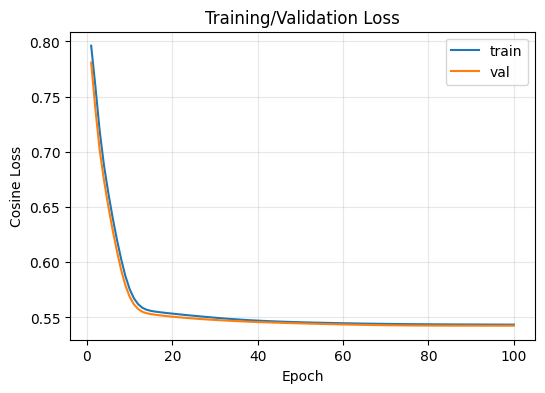

In [14]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_hist) + 1) if 'train_hist' in globals() else []
plt.figure(figsize=(6,4))
if epochs:
    plt.plot(epochs, train_hist, label='train')
    plt.plot(epochs, val_hist, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Cosine Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    print('Run the training cell first to populate train_hist/val_hist.')
plt.show()


## Testing Model with Zero State

In [ ]:
from pqcqec.noise.simple_noise import PennylaneNoisyGates
from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity
import jax.numpy as jnp

noise_model = PennylaneNoisyGates(**NOISE_DIST)
no_noise_model = PennylaneNoisyGates(0,0,0,0)
ZERO_STATE = jnp.zeros((2 ** NUM_QUBITS,), dtype=jnp.complex64).at[0].set(1.0)



In [16]:
print(noise_model)
print(no_noise_model)

PennylaneNoisyGates(x_noise=0.0100, z_noise=0.0100, x_range=[0.0095, 0.0105], z_range=[0.0095, 0.0105])
PennylaneNoisyGates(x_noise=0.0000, z_noise=0.0000, x_range=[0.0000, 0.0000], z_range=[0.0000, 0.0000])


In [17]:
simple_model.eval()  # Set the model to evaluation mode
test_fid_model, test_fid_default, test_fid_data, test_fid_none = [], [], [], []  # Initialize lists to store fidelity results

# Iterate over the test dataset using the dataloader
for i, data in tqdm(enumerate(qc_test_dataloader)):
    data, params, fid = data  # Unpack the batch data into input data, parameters, and fidelity
    input_ids = data['input_ids'].to(device, non_blocking=True)  # Move input IDs to the CUDA device
    attention_mask = data['attention_mask'].to(device, non_blocking=True)  # Move attention mask to the CUDA device
    pqc_params = params[0]  # Extract the PQC parameters as the first sample in the batch

    # Decode the input IDs to get the circuit operations
    circuit_ops = qc_tokenizer.decode(input_ids[0].cpu().numpy().tolist())

    # Predict the PQC parameters using the model
    with amp_autocast(dtype=AMP_DTYPE):  # Use automatic mixed precision for inference
        pred_theta = simple_model(input_ids, attention_mask=attention_mask)[0].detach().to(dtype=torch.float32, device='cpu')

    # Interleave the predicted PQC parameters into the circuit
    model_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pred_theta)

    # Interleave the PQC parameters into the circuit
    pqc_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pqc_params)

    # Compute the ideal output state (with or without uncompensated states)
    ideal_out_state = ZERO_STATE if HAS_UNCOMP else run_circuit_with_noise_model(circuit_ops, ZERO_STATE, no_noise_model, NUM_QUBITS)

    # Simulate the circuit with the model's PQC parameters and noise model
    measured_modelPQC = run_circuit_with_noise_model(model_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # Simulate the circuit with the default PQC parameters and noise model
    measured_defaultPQC = run_circuit_with_noise_model(pqc_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # Simulate the circuit without any PQC parameters and with the noise model
    measured_noPQC = run_circuit_with_noise_model(circuit_ops, ZERO_STATE, noise_model, NUM_QUBITS)

    # Compute the fidelity between the ideal output state and the measured states
    fidelity_modelPQC = jax_pure_state_fidelity(ideal_out_state, measured_modelPQC)
    fidelity_defaultPQC = jax_pure_state_fidelity(ideal_out_state, measured_defaultPQC)
    fidelity_noPQC = jax_pure_state_fidelity(ideal_out_state, measured_noPQC)

    # Append the computed fidelities to their respective lists
    test_fid_model.append(fidelity_modelPQC)
    test_fid_default.append(fidelity_defaultPQC)
    test_fid_data.append(fid[0].item())  # Append the fidelity from the dataset
    test_fid_none.append(fidelity_noPQC)


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


0it [00:00, ?it/s]

In [18]:
print(pred_theta.shape)

torch.Size([4, 5, 3])


In [19]:
model_fid_arr = np.array(test_fid_model)
default_fid_arr = np.array(test_fid_default)
data_fid_arr = np.array(test_fid_data)
none_fid_arr = np.array(test_fid_none)

print(f'Net Fidelity (Model PQC): {np.mean(model_fid_arr):.4e}, Net Fidelity (Default PQC): {np.mean(default_fid_arr):.4e}, '
      f'Net Fidelity (Data): {np.mean(data_fid_arr):.4e}, Net Fidelity (No PQC): {np.mean(none_fid_arr):.4e}')


Net Fidelity (Model PQC): 5.3223e-01, Net Fidelity (Default PQC): 9.9985e-01, Net Fidelity (Data): 9.9983e-01, Net Fidelity (No PQC): 9.9716e-01


Mean of test_fid_data: 0.5322
Median of test_fid_data: 0.5332
Mode of test_fid_data: 0.5457
Min, Max of test_fid_data: 0.1585, 0.8383


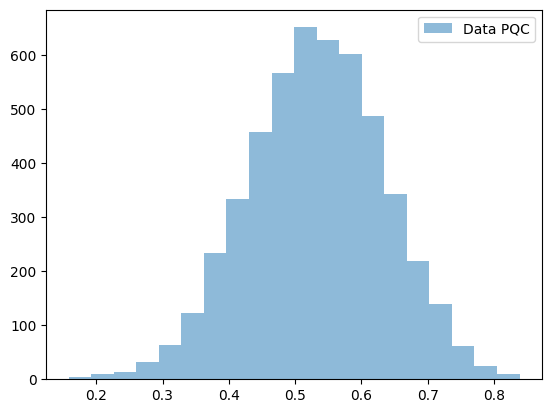

In [20]:
from statistics import mean, median, mode
import matplotlib.pyplot as plt

mean_fid_data = mean(model_fid_arr)
median_fid_data = median(model_fid_arr)
mode_fid_data = mode(model_fid_arr)

print(f"Mean of test_fid_data: {mean_fid_data:.4f}")
print(f"Median of test_fid_data: {median_fid_data:.4f}")
print(f"Mode of test_fid_data: {mode_fid_data:.4f}")
print(f"Min, Max of test_fid_data: {min(model_fid_arr):.4f}, {max(model_fid_arr):.4f}")

plt.hist(model_fid_arr, bins=20, alpha=0.5, label='Data PQC')
plt.legend()
plt.show()


Mean of test_fid_default: 0.9998
Median of test_fid_default: 0.9999
Mode of test_fid_default: 1.0000
Min, Max of test_fid_default: 0.9976, 1.0000


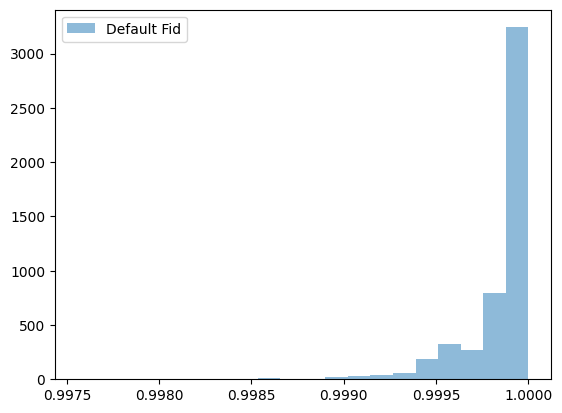

In [21]:
mean_fid_default = mean(default_fid_arr)
median_fid_default = median(default_fid_arr)
mode_fid_default = mode(default_fid_arr)

print(f"Mean of test_fid_default: {mean_fid_default:.4f}")
print(f"Median of test_fid_default: {median_fid_default:.4f}")
print(f"Mode of test_fid_default: {mode_fid_default:.4f}")
print(f"Min, Max of test_fid_default: {min(default_fid_arr):.4f}, {max(default_fid_arr):.4f}")

plt.hist(default_fid_arr, bins=20, alpha=0.5, label='Default Fid')
plt.legend()
plt.show()


Mean of test_fid_data: 0.9998
Median of test_fid_data: 0.9999
Mode of test_fid_data: 1.0000
Min, Max of test_fid_data: 0.9979, 1.0000


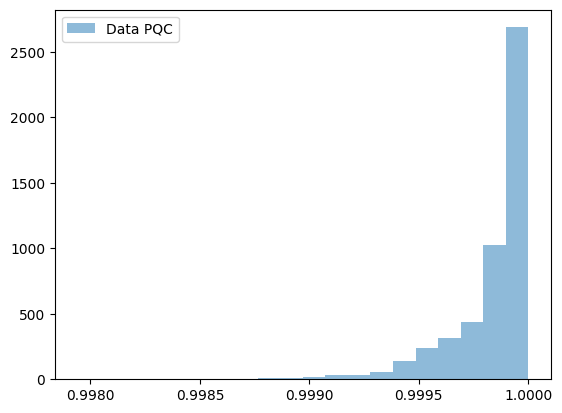

In [22]:
mean_fid_data = mean(data_fid_arr)
median_fid_data = median(data_fid_arr)
mode_fid_data = mode(data_fid_arr)

print(f"Mean of test_fid_data: {mean_fid_data:.4f}")
print(f"Median of test_fid_data: {median_fid_data:.4f}")
print(f"Mode of test_fid_data: {mode_fid_data:.4f}")
print(f"Min, Max of test_fid_data: {min(data_fid_arr):.4f}, {max(data_fid_arr):.4f}")

plt.hist(data_fid_arr, bins=20, alpha=0.5, label='Data PQC')
plt.legend()
plt.show()


Mean of test_fid_data: 0.9972
Median of test_fid_data: 0.9974
Mode of test_fid_data: 0.9975
Min, Max of test_fid_data: 0.9834, 1.0000


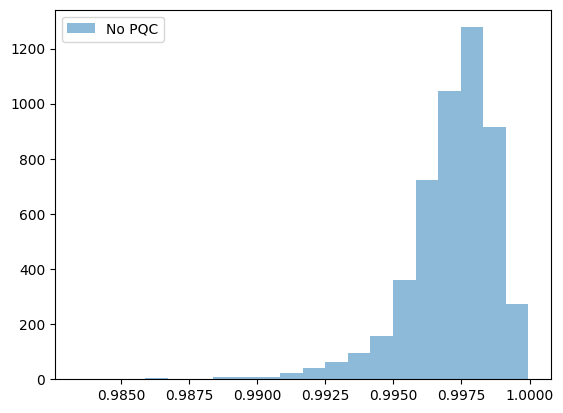

In [23]:
mean_fid_data = mean(none_fid_arr)
median_fid_data = median(none_fid_arr)
mode_fid_data = mode(none_fid_arr)

print(f"Mean of test_fid_data: {mean_fid_data:.4f}")
print(f"Median of test_fid_data: {median_fid_data:.4f}")
print(f"Mode of test_fid_data: {mode_fid_data:.4f}")
print(f"Min, Max of test_fid_data: {min(none_fid_arr):.4f}, {max(none_fid_arr):.4f}")

plt.hist(none_fid_arr, bins=20, alpha=0.5, label='No PQC')
plt.legend()
plt.show()
